# Local Sales Forecast — Visualization

Interactive charts for forecasts written by `python -m forecasting.pipelines.run_all`.

**Prerequisites**
1. Local Postgres `erp_demo` with transactional data
2. Forecast pipeline has been run at least once
3. Kernel: project `.venv` with `prophet`, `matplotlib`, `pandas`

**Charts included** (similar to the Databricks notebook)
- Historical sales trend (order count + quantity)
- Company 12-month forecast with confidence band
- Holdout backtest (actual vs predicted)
- Prophet trend & seasonality components
- Top-SKU material forecasts
- Exogenous drivers (inventory, downtime, production)

In [2]:
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Resolve repo root whether the notebook is opened from repo root or forecasting/notebooks/
_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
REPO_ROOT = next((p for p in _candidates if (p / "forecasting" / "db.py").exists()), Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from forecasting.db import get_forecast_engine
from forecasting.notebooks import plot_utils as plots

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 6)

engine = get_forecast_engine()
company_run_id = plots.latest_run_id(engine, "company")
material_run_id = plots.latest_run_id(engine, "material")

if company_run_id is None:
    raise RuntimeError(
        "No company forecast run found. Run: python -m forecasting.pipelines.run_all"
    )

print(f"Repo root      : {REPO_ROOT}")
print(f"Company run_id : {company_run_id}")
print(f"Material run_id: {material_run_id}")

Repo root      : /Users/yogirajsinhparmar/Documents/projects/supply-chain-poc
Company run_id : 5
Material run_id: 6


## 1. Historical sales trend (gold table)

Same idea as the Databricks EDA cell: monthly order count and total quantity from `forecast_serve.sales_trend_monthly`.

Shape      : (61, 4)
Date range : 2021-07-01 → 2026-07-01


,order_count,total_quantity
count,61.0,61.0
mean,168.0,2152493.0
std,32.0,498642.0
min,114.0,1103059.0
25%,144.0,1784371.0
50%,165.0,2138603.0
75%,200.0,2668178.0
max,229.0,2998113.0


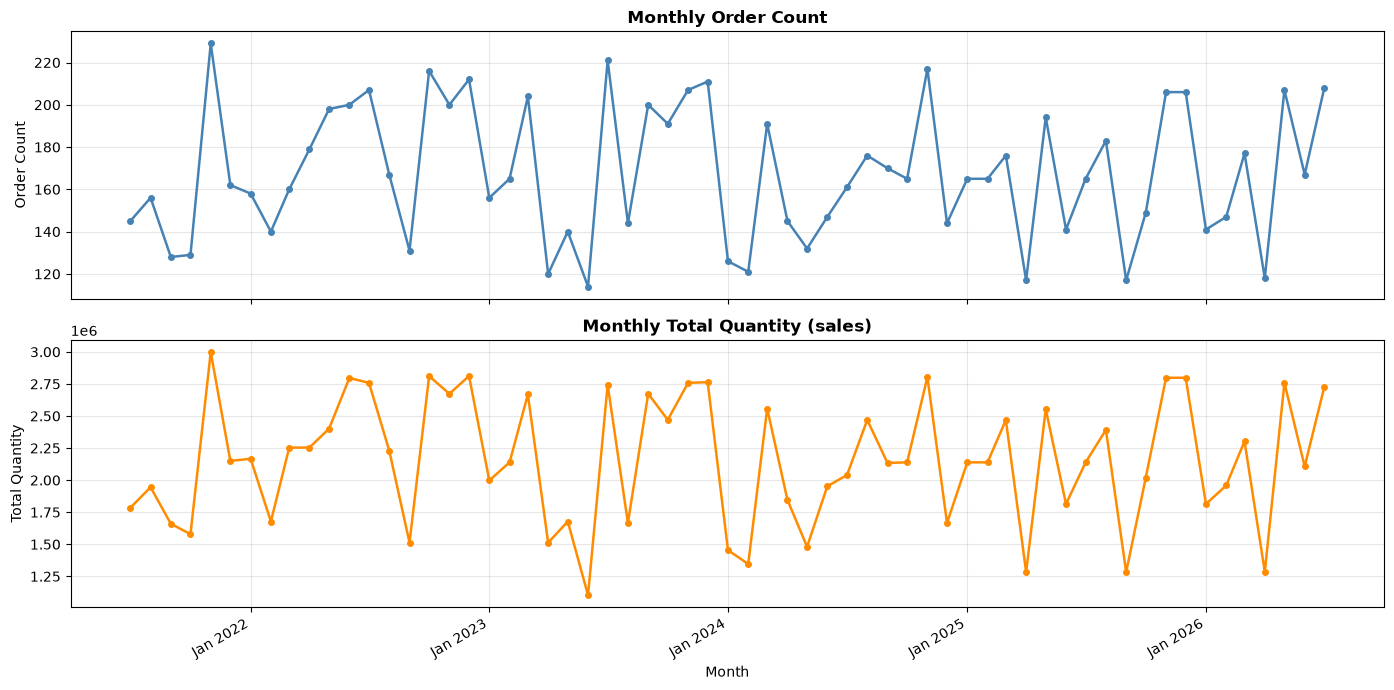

In [3]:
trend = pd.read_sql(
    """
    SELECT month_start_date, year_month, order_count, total_quantity
    FROM forecast_serve.sales_trend_monthly
    ORDER BY month_start_date
    """,
    engine,
    parse_dates=["month_start_date"],
)

print(f"Shape      : {trend.shape}")
print(f"Date range : {trend['month_start_date'].min().date()} → {trend['month_start_date'].max().date()}")
display(trend[["order_count", "total_quantity"]].describe().round(0))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(trend["month_start_date"], trend["order_count"],
             marker="o", ms=4, linewidth=1.8, color="steelblue")
axes[0].set_title("Monthly Order Count", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Order Count")
axes[0].grid(True, alpha=0.3)

axes[1].plot(trend["month_start_date"], trend["total_quantity"],
             marker="o", ms=4, linewidth=1.8, color="darkorange")
axes[1].set_title("Monthly Total Quantity (sales)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total Quantity")
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## 2. Company forecast — historical + next 12 months

Target: **sales quantity** (units). Forecast band is the model's 95% interval.

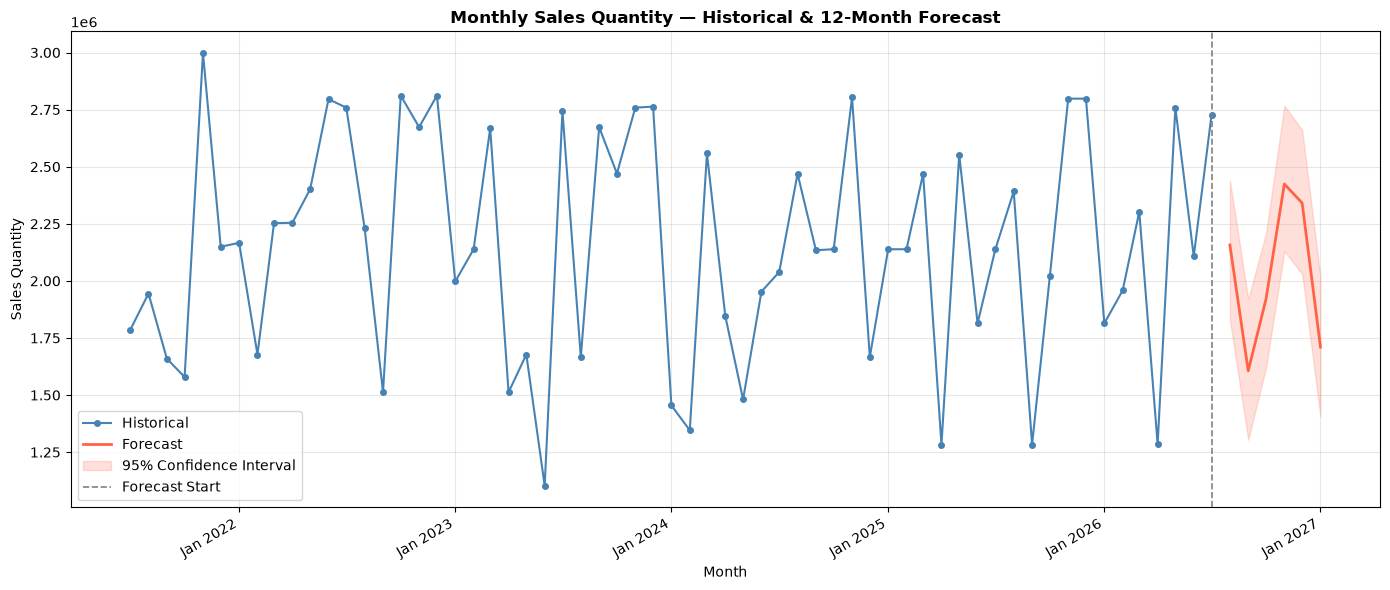

,Month,Forecast,Lower,Upper
0,2026-08,2157274,1831659,2440391
1,2026-09,1606228,1304186,1919777
2,2026-10,1920174,1619648,2207954
3,2026-11,2424312,2130183,2767146
4,2026-12,2341232,2031220,2661213
5,2027-01,1710071,1404209,2016870


In [4]:
company_hist = plots.load_company_history(engine)
company_fc = plots.load_company_forecast(engine, company_run_id)

plots.plot_history_and_forecast(
    company_hist,
    company_fc,
    date_col="month_start_date",
    value_col="sales_quantity",
    title="Monthly Sales Quantity — Historical & 12-Month Forecast",
    ylabel="Sales Quantity",
)
plt.show()

next12 = company_fc.copy()
next12[["yhat", "yhat_lower", "yhat_upper"]] = next12[["yhat", "yhat_lower", "yhat_upper"]].round(0).astype(int)
next12 = next12.rename(columns={
    "year_month": "Month",
    "yhat": "Forecast",
    "yhat_lower": "Lower",
    "yhat_upper": "Upper",
})
display(next12[["Month", "Forecast", "Lower", "Upper"]])

## 3. Holdout backtest (last 6 months)

How the model performed on months it had not seen during training.

Company backtest metrics:


,value
metric_name,
mae,297520.55
mape,13.09
rmse,400261.84
wmape,13.59


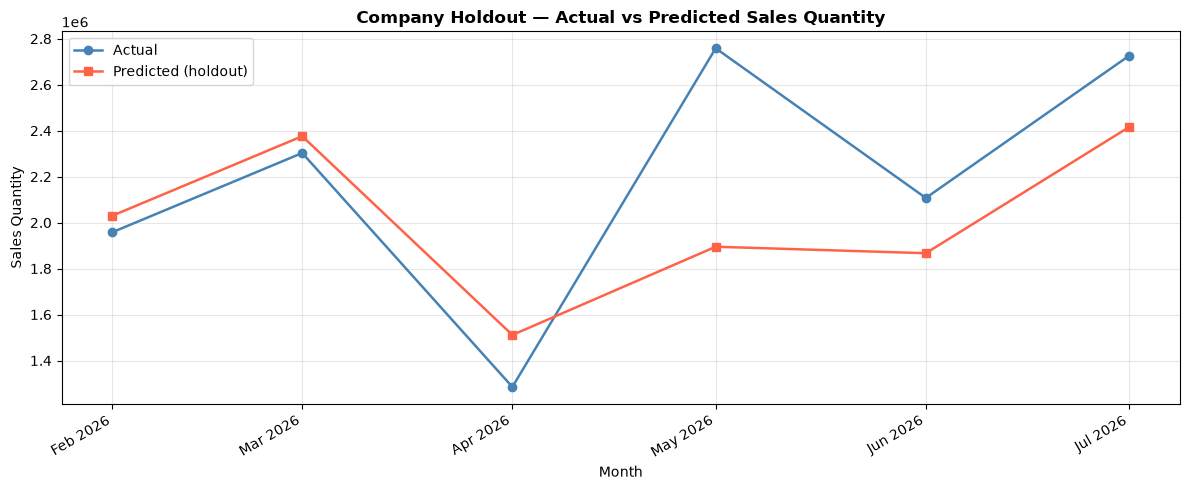

,Month,Actual,Predicted,Error
0,2026-02,1958408.0,2030288.0,-71880.0
1,2026-03,2302846.0,2375909.0,-73063.0
2,2026-04,1285148.0,1511186.0,-226038.0
3,2026-05,2758552.0,1895068.0,863484.0
4,2026-06,2107318.0,1866930.0,240388.0
5,2026-07,2726263.0,2415993.0,310270.0


In [5]:
company_bt = plots.load_backtest_detail(engine, company_run_id, "COMPANY")
company_metrics = plots.load_backtest_metrics(engine, company_run_id)
company_metrics_company = company_metrics[company_metrics["grain_id"] == "COMPANY"]

metric_pivot = company_metrics_company.set_index("metric_name")["metric_value"].round(2)
print("Company backtest metrics:")
display(metric_pivot.to_frame("value"))

plots.plot_backtest(
    company_bt,
    title="Company Holdout — Actual vs Predicted Sales Quantity",
    ylabel="Sales Quantity",
)
plt.show()

comparison = company_bt.copy()
comparison["forecast_month"] = comparison["forecast_month"].dt.strftime("%Y-%m")
comparison = comparison.round(0)
display(comparison.rename(columns={
    "forecast_month": "Month",
    "actual": "Actual",
    "predicted": "Predicted",
    "error": "Error",
}))

## 4. Prophet components (trend & yearly seasonality)

Refits the company Prophet model locally so we can decompose the forecast — same chart style as the Databricks notebook.

/Users/yogirajsinhparmar/Documents/projects/supply-chain-poc/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
11:11:11 - cmdstanpy - INFO - Chain [1] start processing
11:11:12 - cmdstanpy - INFO - Chain [1] done processing


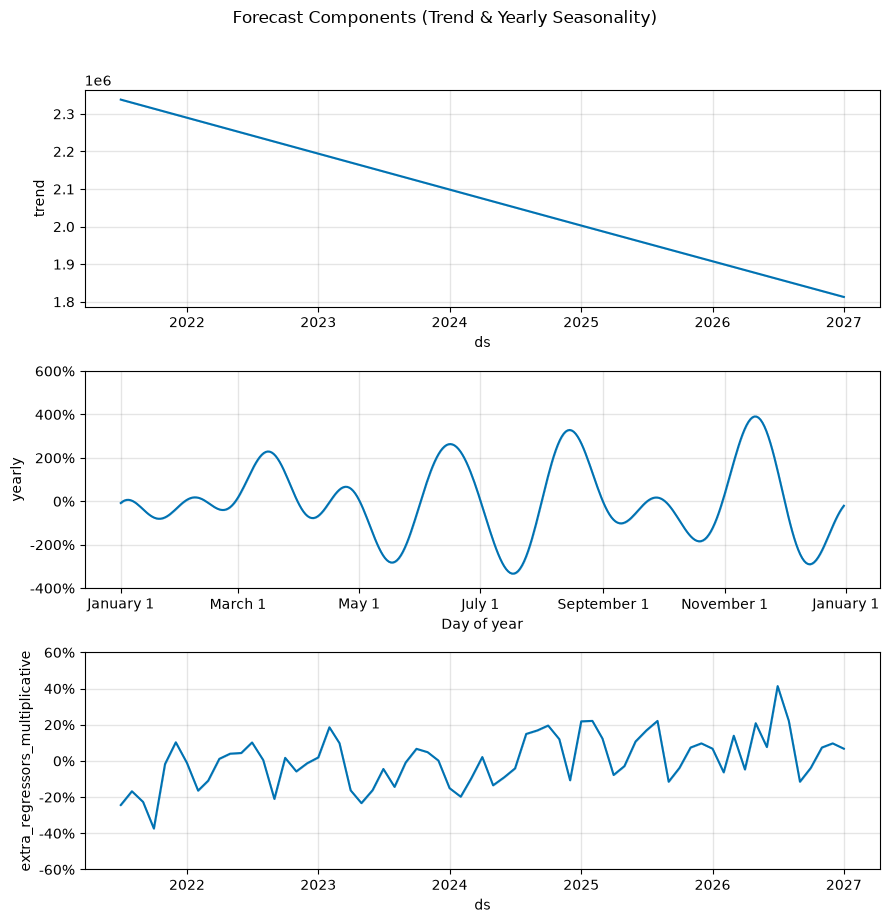

In [6]:
import json

from prophet import Prophet

from forecasting.config import DEFAULT_CONFIG

run_meta = pd.read_sql(
    f"SELECT params_json, horizon_months FROM forecast_ml.forecast_runs WHERE run_id = {company_run_id}",
    engine,
).iloc[0]

params = json.loads(run_meta["params_json"]) if isinstance(run_meta["params_json"], str) else run_meta["params_json"]
regressors = params.get("regressors", list(DEFAULT_CONFIG.regressors))
horizon = int(run_meta["horizon_months"])

features = company_hist.copy()
features["ds"] = pd.to_datetime(features["month_start_date"])
features["y"] = features["sales_quantity"].astype(float)
for col in regressors:
    if col not in features.columns:
        features[col] = 0.0

# Use only regressors with variation (matches training logic)
active = [c for c in regressors if c in features.columns and features[c].astype(float).std() > 1e-9]

model = Prophet(
    seasonality_mode=params.get("seasonality_mode", DEFAULT_CONFIG.seasonality_mode),
    yearly_seasonality=params.get("yearly_seasonality", True),
    weekly_seasonality=params.get("weekly_seasonality", False),
    daily_seasonality=params.get("daily_seasonality", False),
    changepoint_prior_scale=params.get("changepoint_prior_scale", 0.1),
    seasonality_prior_scale=params.get("seasonality_prior_scale", 10.0),
)
for col in active:
    model.add_regressor(col)

model.fit(features[["ds", "y", *active]])
future = model.make_future_dataframe(periods=horizon, freq="MS")

# Fill future regressors with same-month-last-year (simple mirror of pipeline)
for col in active:
    hist_map = features.set_index("ds")[col]
    vals = []
    for ds in future["ds"]:
        if ds in hist_map.index:
            vals.append(float(hist_map.loc[ds]))
        else:
            lag = ds - pd.DateOffset(years=1)
            vals.append(float(hist_map.loc[lag]) if lag in hist_map.index else float(hist_map.tail(3).mean()))
    future[col] = vals

forecast_full = model.predict(future)
fig2 = model.plot_components(forecast_full)
plt.suptitle("Forecast Components (Trend & Yearly Seasonality)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 5. Exogenous drivers (company level)

Signals fed into the Prophet model alongside sales history.

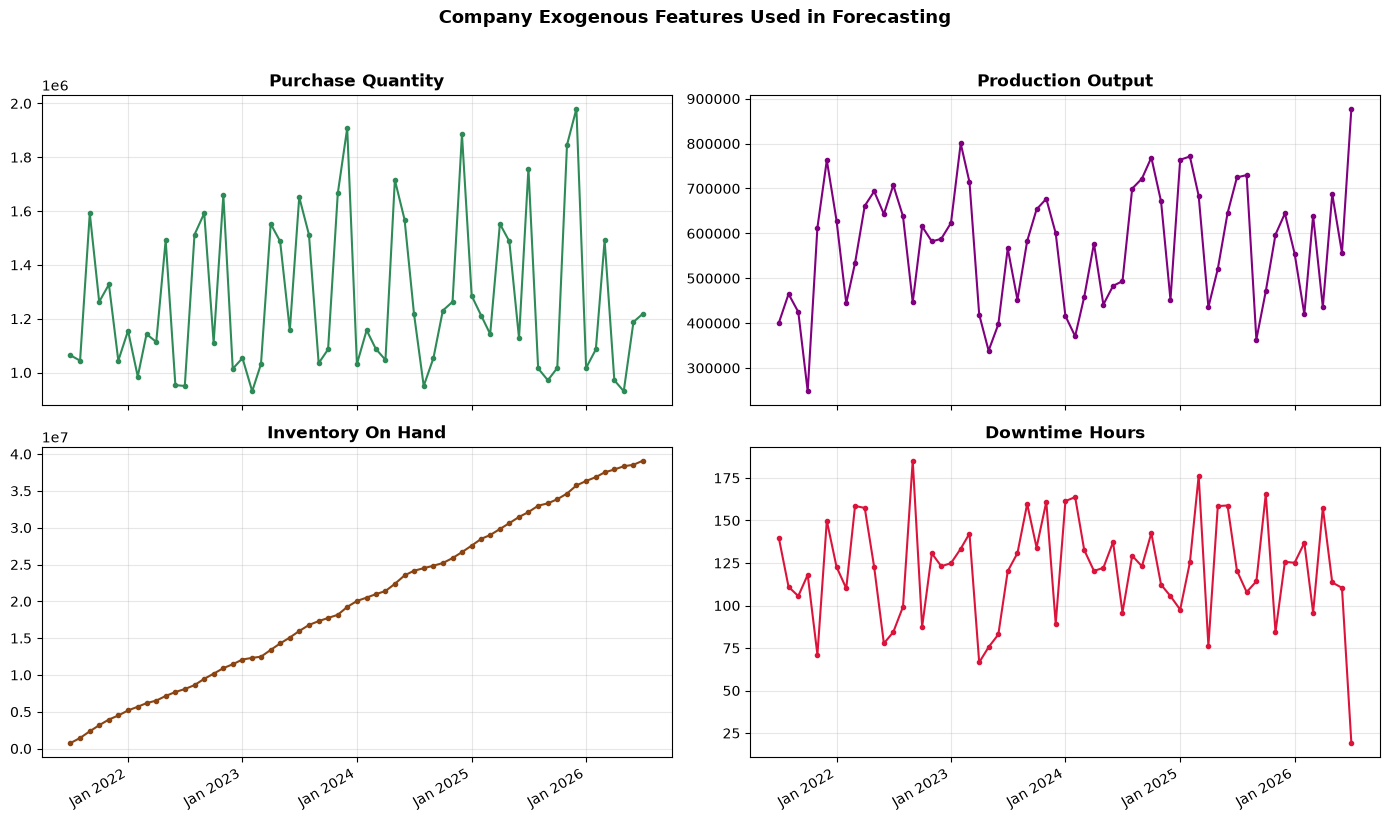

In [7]:
drivers = company_hist.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
series = [
    ("purchase_quantity", "Purchase Quantity", "seagreen"),
    ("production_output_quantity", "Production Output", "purple"),
    ("inventory_on_hand", "Inventory On Hand", "saddlebrown"),
    ("downtime_hours", "Downtime Hours", "crimson"),
]

for ax, (col, label, color) in zip(axes.ravel(), series):
    ax.plot(drivers["month_start_date"], drivers[col], marker="o", ms=3, color=color, linewidth=1.5)
    ax.set_title(label, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

fig.suptitle("Company Exogenous Features Used in Forecasting", fontsize=13, fontweight="bold", y=1.02)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## 6. Top materials — forecast charts

One chart per top-selling finished good. Use **wMAPE** (volume-weighted) to judge SKU accuracy — MAPE can spike when a month is near zero.

,sales_rank,material_id,material_name,sold_quantity
0,1,FG0045,2L Trigger Spray Bottle,3240635
1,2,FG0042,20L HDPE Bottle,2541972
2,3,FG0064,1.5L PP Jar,2420293
3,4,FG0085,1.5L Clamshell Container,2378046
4,5,FG0086,10L Squeeze Tube,2361998
5,6,FG0074,20L Trigger Spray Bottle,2345070
6,7,FG0005,2L Squeeze Tube,2199795
7,8,FG0051,1.5L HDPE Bottle,2098615
8,9,FG0001,750ml PET Preform,2079015
9,10,FG0097,330ml Squeeze Tube,2026648


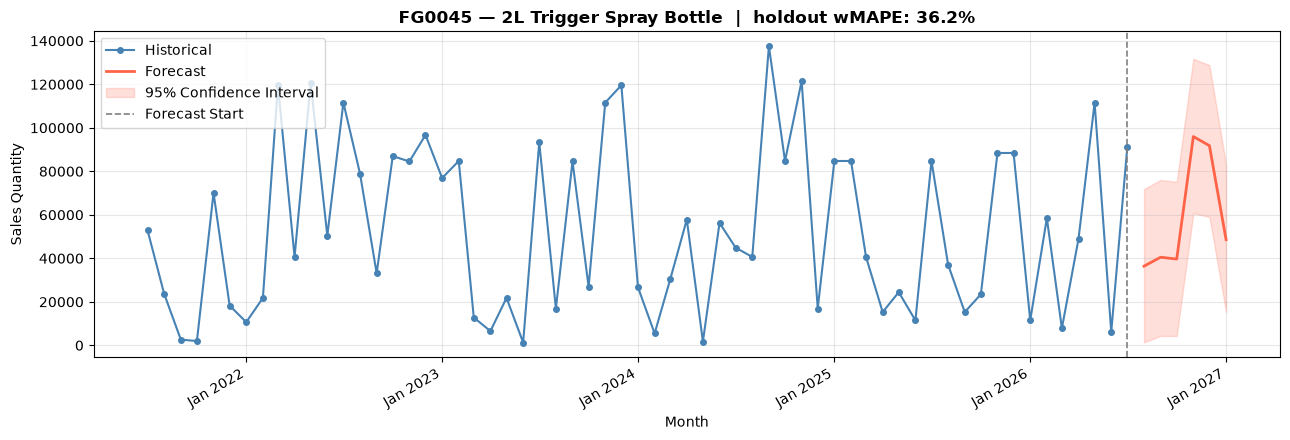

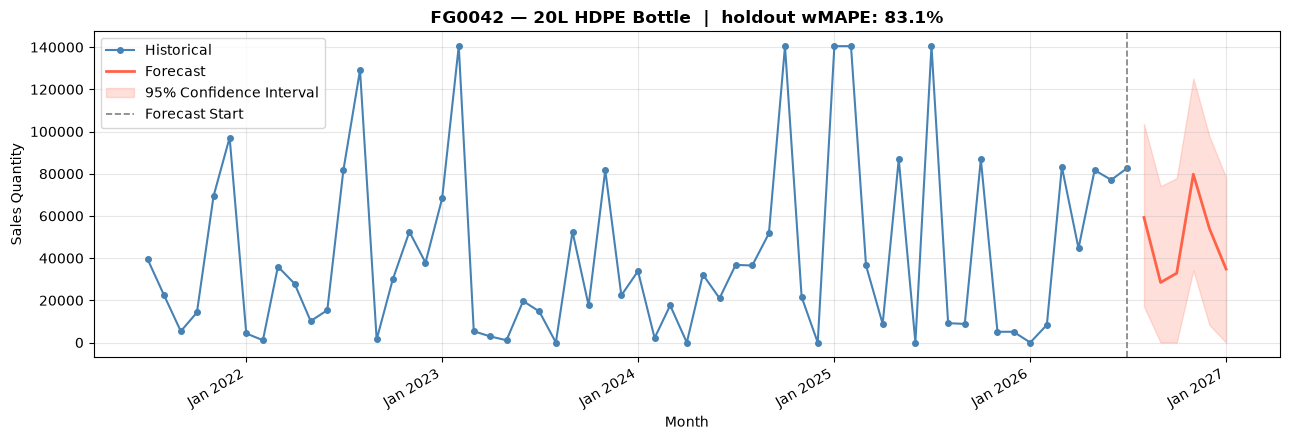

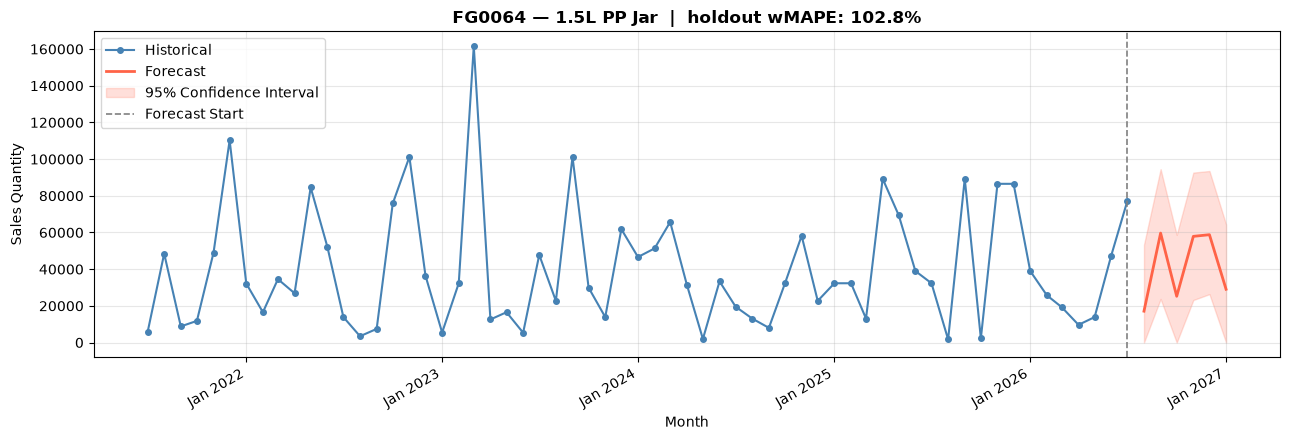

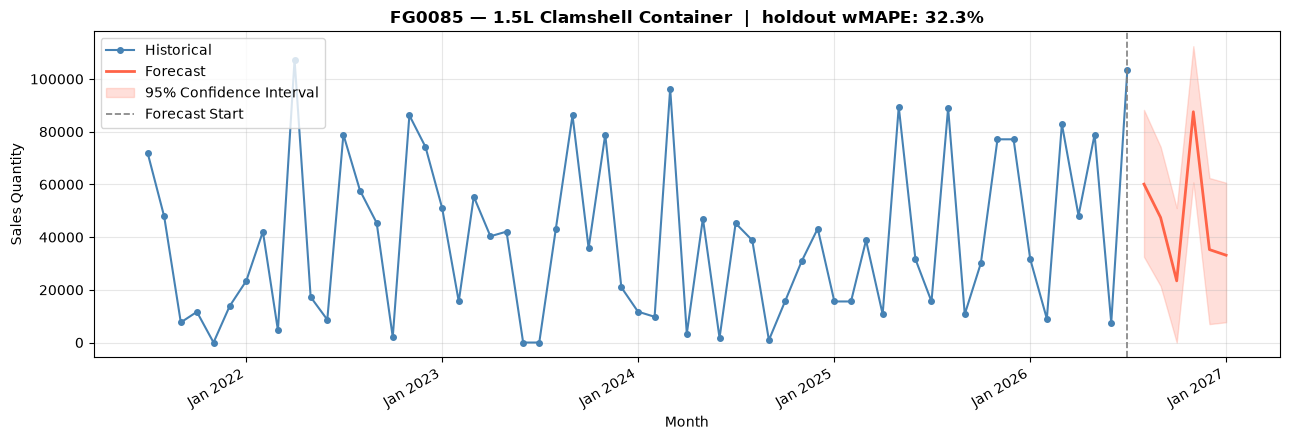

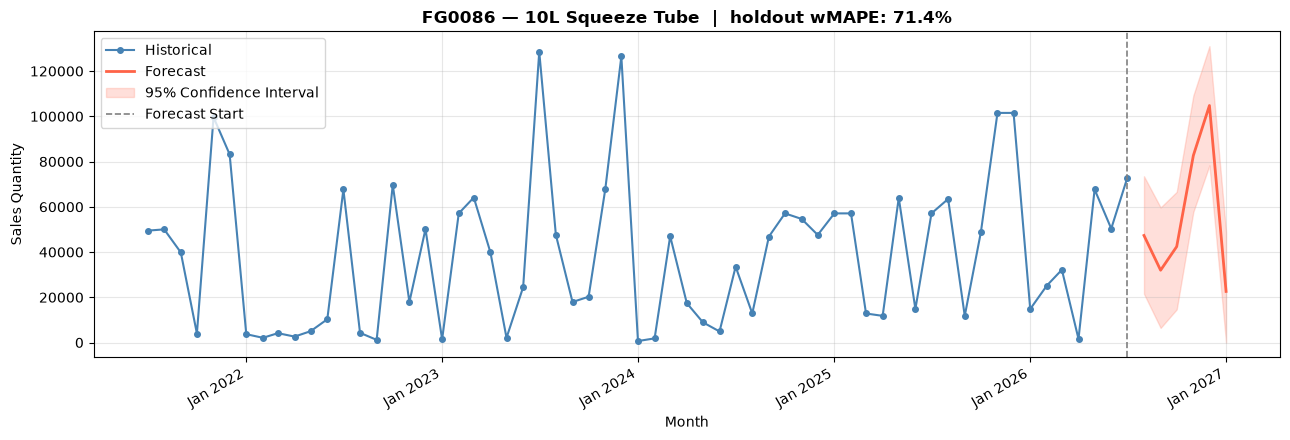

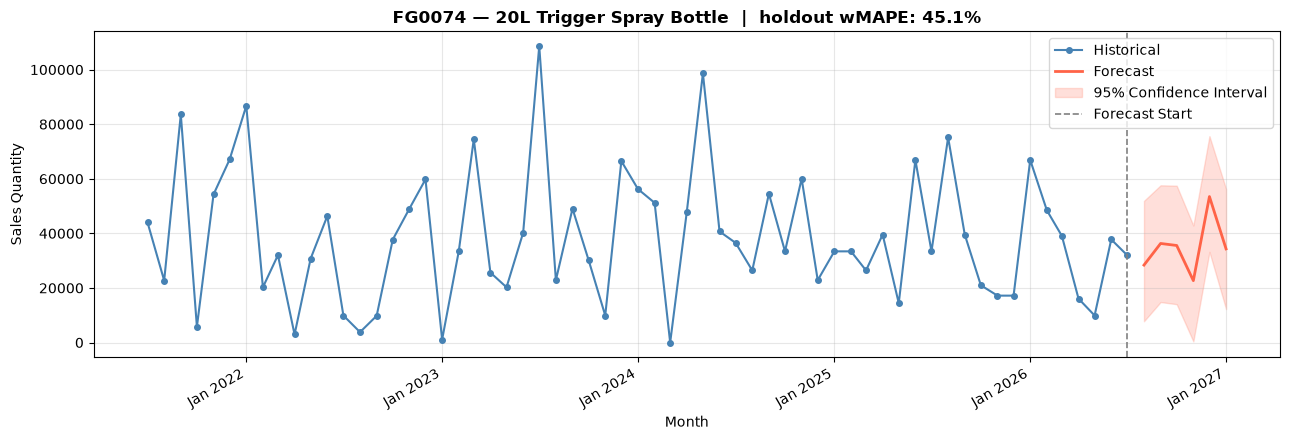

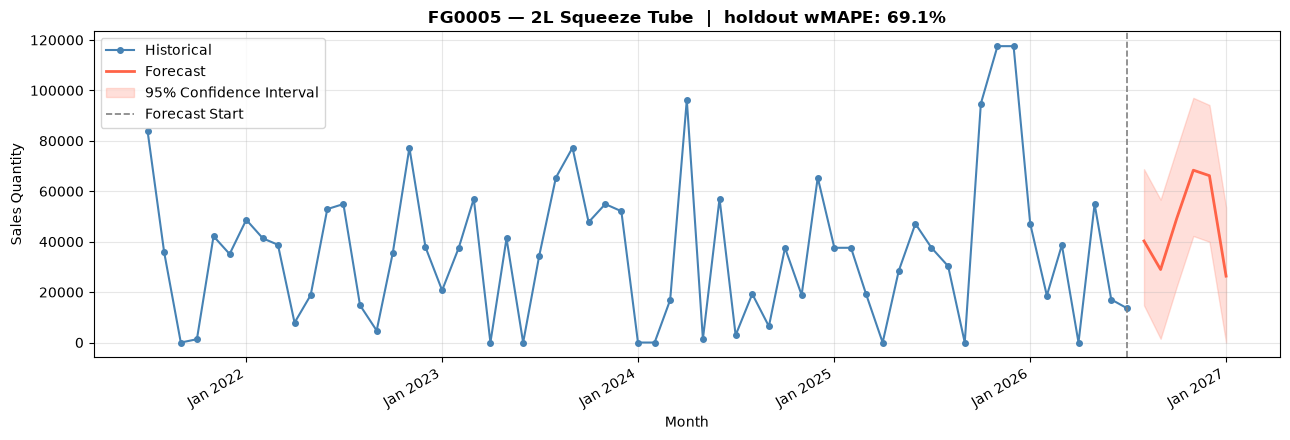

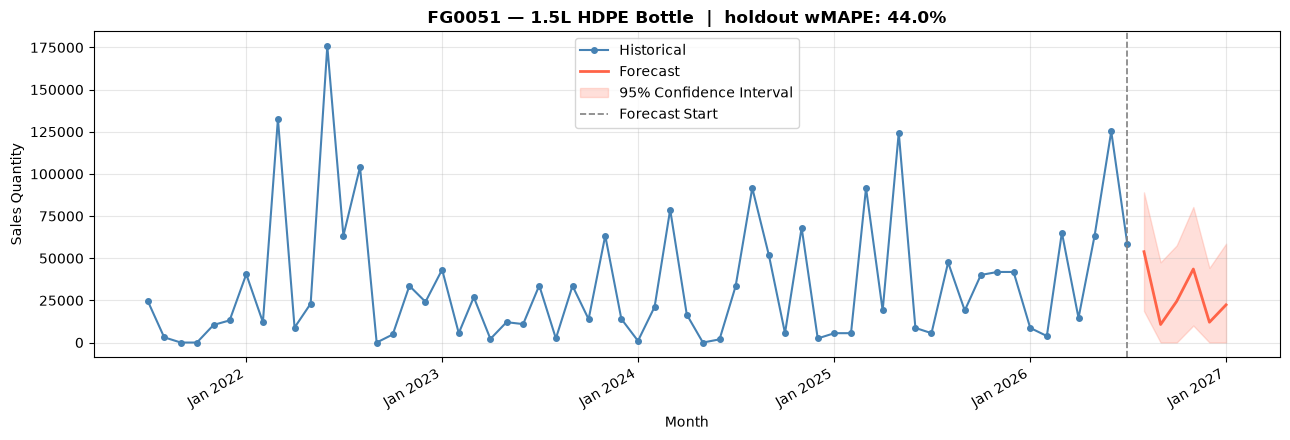

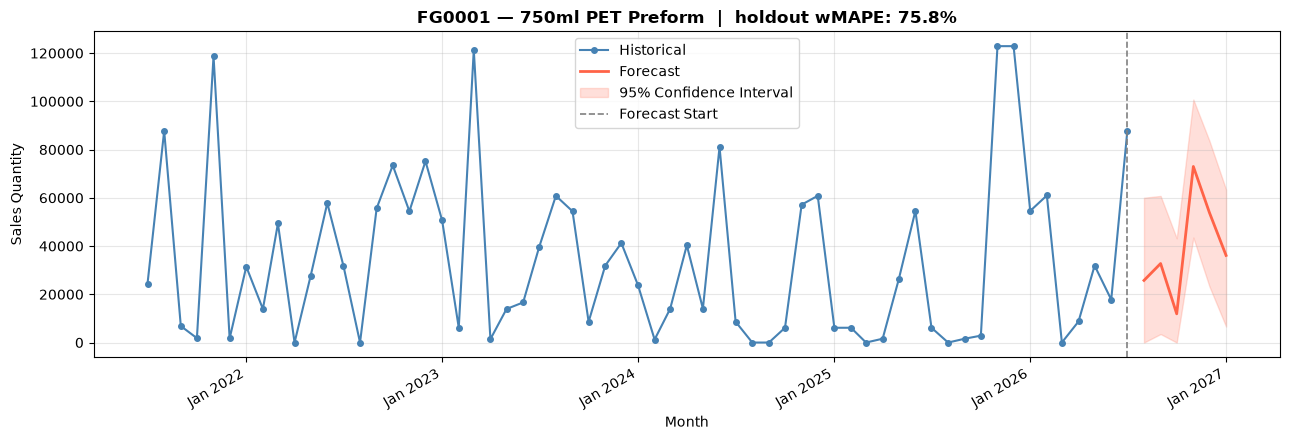

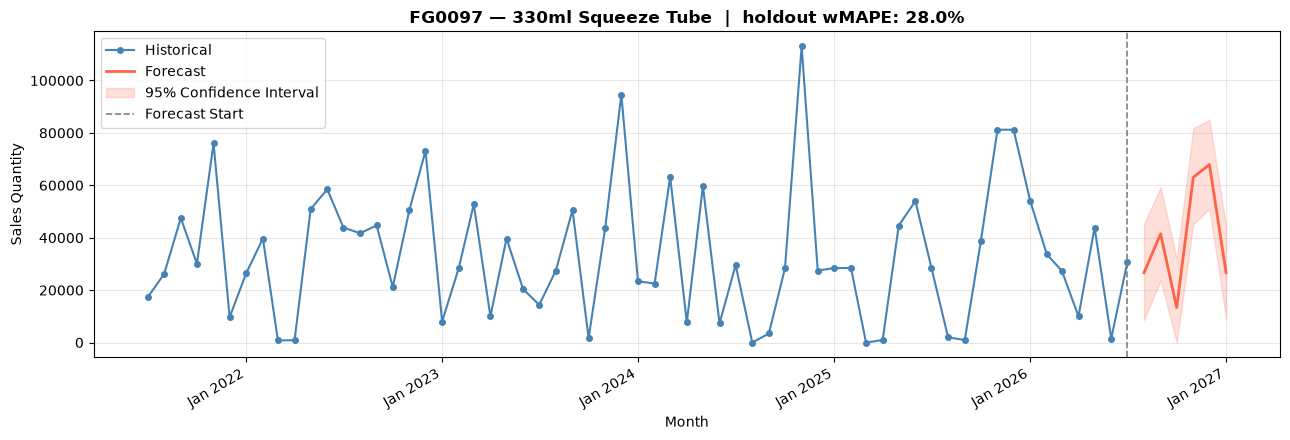

In [8]:
if material_run_id is None:
    print("No material run found — skip material charts or re-run pipeline.")
else:
    top = plots.load_top_materials(engine)
    mat_metrics = plots.load_backtest_metrics(engine, material_run_id)
    wmape = (
        mat_metrics[mat_metrics["metric_name"] == "wmape"]
        .set_index("grain_id")["metric_value"]
        .round(1)
    )

    display(top[["sales_rank", "material_id", "material_name", "sold_quantity"]])

    for _, row in top.iterrows():
        mid = row["material_id"]
        name = row["material_name"]
        hist = plots.load_material_history(engine, mid)
        fc = plots.load_material_forecast(engine, material_run_id, mid)
        sku_wmape = wmape.get(mid, float("nan"))

        plots.plot_history_and_forecast(
            hist,
            fc,
            date_col="month_start_date",
            value_col="sales_quantity",
            title=f"{mid} — {name}  |  holdout wMAPE: {sku_wmape:.1f}%",
            ylabel="Sales Quantity",
            figsize=(13, 4.5),
        )
        plt.show()

## 7. Material backtest quality (bar chart)

Lower wMAPE = better volume-weighted accuracy on the last 6 holdout months.

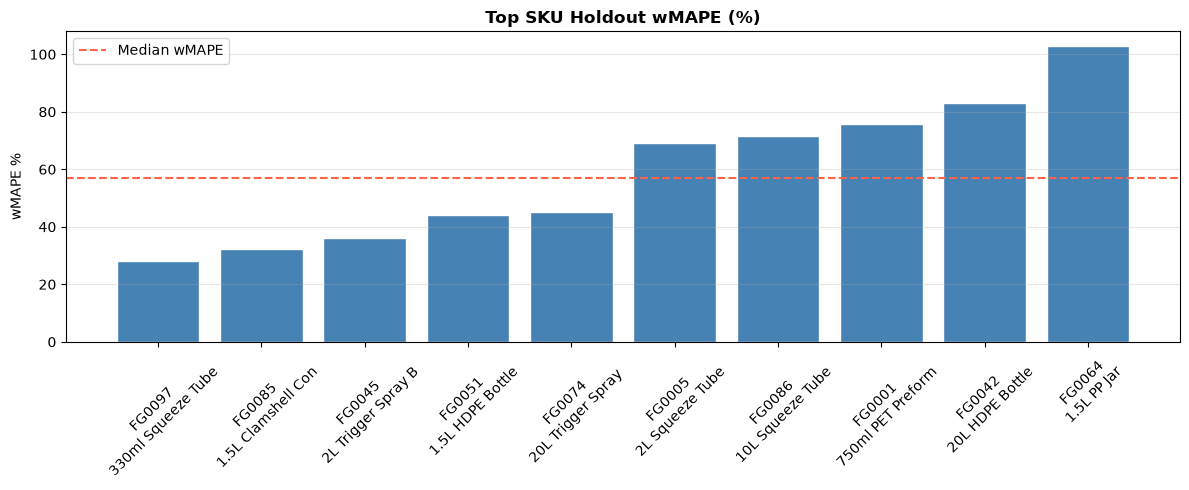

In [10]:
if material_run_id is not None:
    wmape_df = (
        mat_metrics[mat_metrics["metric_name"] == "wmape"]
        .rename(columns={"grain_id": "material_id"})
        .merge(top[["material_id", "material_name"]], on="material_id", how="inner")
        .sort_values("metric_value")
    )
    labels = wmape_df["material_id"] + "\n" + wmape_df["material_name"].str.slice(0, 18)

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(labels, wmape_df["metric_value"], color="steelblue", edgecolor="white")
    ax.axhline(wmape_df["metric_value"].median(), color="tomato", linestyle="--", label="Median wMAPE")
    ax.set_title("Top SKU Holdout wMAPE (%)", fontweight="bold")
    ax.set_ylabel("wMAPE %")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()